In [32]:
import pandas as pd
import numpy as np

# Load Users dataset
users = pd.read_csv("data/EduPro Online Platform.xlsx - Users (1).csv")

# Show first 5 rows
users.head()

,UserID,UserName,Age,Gender,Email
0,U00001,wilsonjordan,15,Male,patricia27@hotmail.com
1,U00002,angela22,29,Female,hallrandy@hotmail.com
2,U00003,morrisonamanda,33,Female,ganderson@yahoo.com
3,U00004,fthornton,23,Female,christensencatherine@outlook.com
4,U00005,fostergeoffrey,21,Male,karenfuentes@yahoo.com


In [33]:
# Number of rows and columns
print(users.shape)

# Column names and data types
print(users.info())

(3000, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   UserID    3000 non-null   object
 1   UserName  3000 non-null   object
 2   Age       3000 non-null   int64 
 3   Gender    3000 non-null   object
 4   Email     3000 non-null   object
dtypes: int64(1), object(4)
memory usage: 117.3+ KB
None


In [34]:
users.isnull().sum()

UserID      0
UserName    0
Age         0
Gender      0
Email       0
dtype: int64

In [35]:
users.duplicated().sum()

np.int64(0)

In [36]:
users.describe()

,Age
count,3000.000000
mean,24.974333
std,6.046475
min,15.000000
25%,20.000000
50%,25.000000
75%,30.000000
max,35.000000


In [37]:
users.columns

Index(['UserID', 'UserName', 'Age', 'Gender', 'Email'], dtype='object')

In [38]:
users.head()
users.shape
users.info()
users.isnull().sum()
users.duplicated().sum()
users.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   UserID    3000 non-null   object
 1   UserName  3000 non-null   object
 2   Age       3000 non-null   int64 
 3   Gender    3000 non-null   object
 4   Email     3000 non-null   object
dtypes: int64(1), object(4)
memory usage: 117.3+ KB


,Age
count,3000.000000
mean,24.974333
std,6.046475
min,15.000000
25%,20.000000
50%,25.000000
75%,30.000000
max,35.000000


Total Students

In [39]:
print("Total Students:", users.shape[0])

Total Students: 3000


Age Distribution

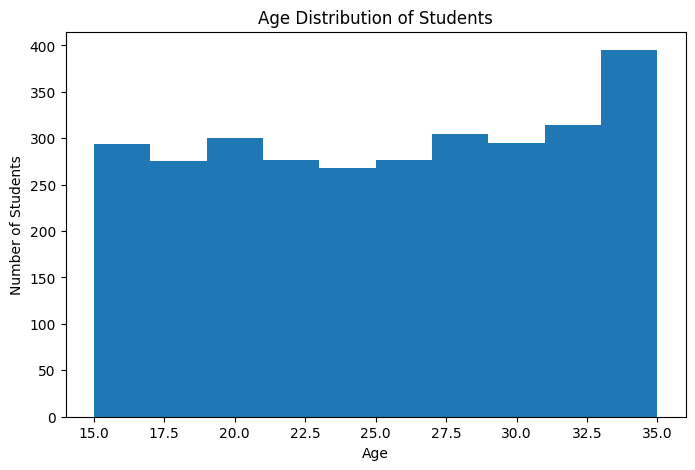

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(users["Age"], bins=10)

plt.title("Age Distribution of Students")
plt.xlabel("Age")
plt.ylabel("Number of Students")

plt.show()

Gender Distributionx

In [41]:
users["Gender"].value_counts()


Gender
Female    1520
Male      1480
Name: count, dtype: int64

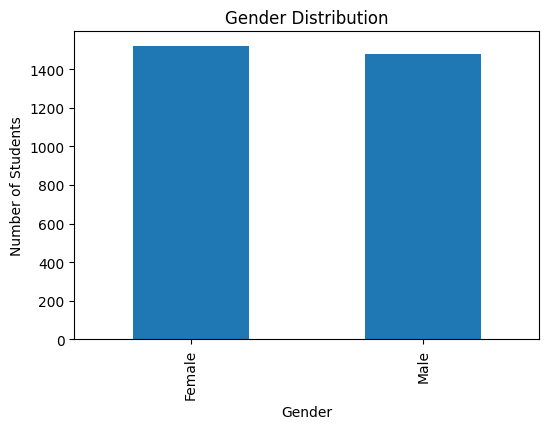

In [42]:
users["Gender"].value_counts().plot(kind="bar", figsize=(6,4))

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Students")

plt.show()

In [43]:
(users["Gender"].value_counts(normalize=True) * 100).round(2)

Gender
Female    50.67
Male      49.33
Name: proportion, dtype: float64

In [44]:
print("Minimum Age :", users["Age"].min())
print("Maximum Age :", users["Age"].max())
print("Average Age :", round(users["Age"].mean(),2))
print("Median Age  :", users["Age"].median())

Minimum Age : 15
Maximum Age : 35
Average Age : 24.97
Median Age  : 25.0


In [45]:
# Create Age Groups
users["AgeGroup"] = pd.cut(
    users["Age"],
    bins=[14, 20, 30, 40, 50, 60],
    labels=["15-20", "21-30", "31-40", "41-50", "51-60"]
)

users.head()

,UserID,UserName,Age,Gender,Email,AgeGroup
0,U00001,wilsonjordan,15,Male,patricia27@hotmail.com,15-20
1,U00002,angela22,29,Female,hallrandy@hotmail.com,21-30
2,U00003,morrisonamanda,33,Female,ganderson@yahoo.com,31-40
3,U00004,fthornton,23,Female,christensencatherine@outlook.com,21-30
4,U00005,fostergeoffrey,21,Male,karenfuentes@yahoo.com,21-30


In [46]:
#Count Students in Each Age Group
# Count Students in Each Age Group
users["AgeGroup"].value_counts().sort_index()

AgeGroup
15-20     869
21-30    1422
31-40     709
41-50       0
51-60       0
Name: count, dtype: int64

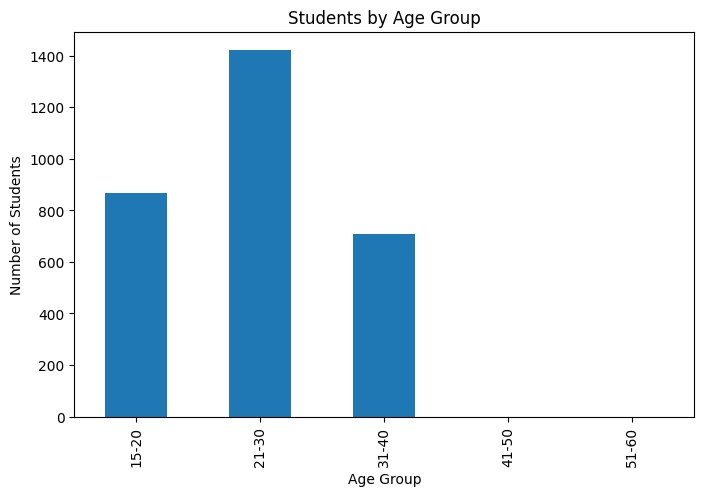

In [47]:
#Visualize Age Groups
import matplotlib.pyplot as plt

users["AgeGroup"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Students by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Students")
plt.show()

In [48]:
#Visualize Age Groups   
users["GenderEncoded"] = users["Gender"].map({
    "Male": 0,
    "Female": 1
})

users.head()

,UserID,UserName,Age,Gender,Email,AgeGroup,GenderEncoded
0,U00001,wilsonjordan,15,Male,patricia27@hotmail.com,15-20,0
1,U00002,angela22,29,Female,hallrandy@hotmail.com,21-30,1
2,U00003,morrisonamanda,33,Female,ganderson@yahoo.com,31-40,1
3,U00004,fthornton,23,Female,christensencatherine@outlook.com,21-30,1
4,U00005,fostergeoffrey,21,Male,karenfuentes@yahoo.com,21-30,0


Create Student Profile DataFrame

In [49]:
# Create Student Profile
student_profile = users.copy()

student_profile.head()

,UserID,UserName,Age,Gender,Email,AgeGroup,GenderEncoded
0,U00001,wilsonjordan,15,Male,patricia27@hotmail.com,15-20,0
1,U00002,angela22,29,Female,hallrandy@hotmail.com,21-30,1
2,U00003,morrisonamanda,33,Female,ganderson@yahoo.com,31-40,1
3,U00004,fthornton,23,Female,christensencatherine@outlook.com,21-30,1
4,U00005,fostergeoffrey,21,Male,karenfuentes@yahoo.com,21-30,0


In [50]:
student_profile = student_profile[
    ["UserID", "Age", "AgeGroup", "Gender", "GenderEncoded"]
]

student_profile.head()

,UserID,Age,AgeGroup,Gender,GenderEncoded
0,U00001,15,15-20,Male,0
1,U00002,29,21-30,Female,1
2,U00003,33,31-40,Female,1
3,U00004,23,21-30,Female,1
4,U00005,21,21-30,Male,0


In [51]:
#Save Student Profile
student_profile.to_csv(
    "data/student_profile.csv",
    index=False
)


print("Student Profile Saved Successfully!")

Student Profile Saved Successfully!


In [52]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

In [53]:
# Create Label Encoder object
label_encoder = LabelEncoder()

In [54]:
student_profile["AgeGroupEncoded"] = label_encoder.fit_transform(
    student_profile["AgeGroup"]
)

student_profile.head()

,UserID,Age,AgeGroup,Gender,GenderEncoded,AgeGroupEncoded
0,U00001,15,15-20,Male,0,0
1,U00002,29,21-30,Female,1,1
2,U00003,33,31-40,Female,1,2
3,U00004,23,21-30,Female,1,1
4,U00005,21,21-30,Male,0,1


In [55]:
# Select only numerical features for ML
ml_features = student_profile[
    ["Age", "GenderEncoded", "AgeGroupEncoded"]
]

ml_features.head()

,Age,GenderEncoded,AgeGroupEncoded
0,15,0,0
1,29,1,1
2,33,1,2
3,23,1,1
4,21,0,1


In [56]:
from sklearn.preprocessing import StandardScaler

In [57]:
# Create scaler object
scaler = StandardScaler()

In [58]:
from sklearn.preprocessing import StandardScaler

# Create scaler object
scaler = StandardScaler()

In [60]:
# Scale the numerical features
X_scaled = scaler.fit_transform(ml_features)

In [61]:
# Scale the numerical features
X_scaled = scaler.fit_transform(ml_features)

print("Shape:", X_scaled.shape)

Shape: (3000, 3)


In [62]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)

    inertia.append(model.inertia_)

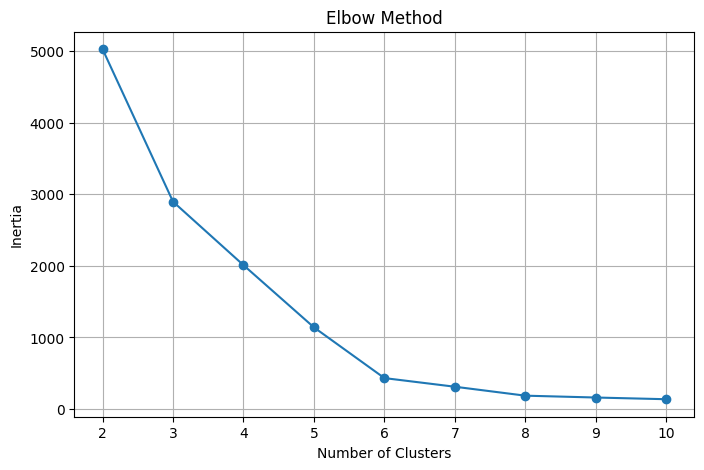

In [63]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    inertia,
    marker="o"
)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.grid(True)

plt.show()

In [64]:
from sklearn.metrics import silhouette_score

for k in range(2,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    print(f"K={k}  Score={score:.3f}")

K=2  Score=0.435
K=3  Score=0.525
K=4  Score=0.553
K=5  Score=0.663
K=6  Score=0.757
K=7  Score=0.748
K=8  Score=0.738
K=9  Score=0.719
K=10  Score=0.695


In [65]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

In [66]:
student_profile["Cluster"] = clusters

student_profile.head()

,UserID,Age,AgeGroup,Gender,GenderEncoded,AgeGroupEncoded,Cluster
0,U00001,15,15-20,Male,0,0,1
1,U00002,29,21-30,Female,1,1,0
2,U00003,33,31-40,Female,1,2,3
3,U00004,23,21-30,Female,1,1,0
4,U00005,21,21-30,Male,0,1,2


In [67]:
student_profile["Cluster"].value_counts()

Cluster
1    869
0    729
3    709
2    693
Name: count, dtype: int64

In [68]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

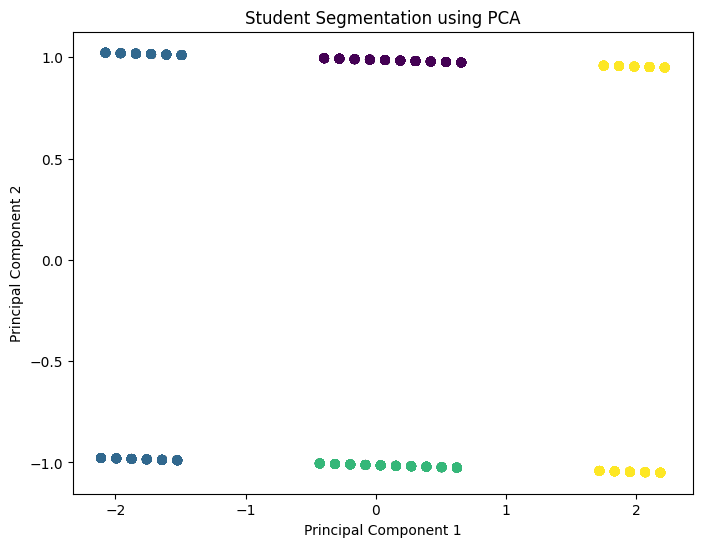

In [69]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters,
    cmap="viridis"
)

plt.title("Student Segmentation using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

In [70]:
segment_names = {
    0: "Young Female Learners",
    1: "Young Male Learners",
    2: "Adult Female Learners",
    3: "Adult Male Learners"
}

student_profile["Segment"] = (
    student_profile["Cluster"].map(segment_names)
)

student_profile.head()

,UserID,Age,AgeGroup,Gender,GenderEncoded,AgeGroupEncoded,Cluster,Segment
0,U00001,15,15-20,Male,0,0,1,Young Male Learners
1,U00002,29,21-30,Female,1,1,0,Young Female Learners
2,U00003,33,31-40,Female,1,2,3,Adult Male Learners
3,U00004,23,21-30,Female,1,1,0,Young Female Learners
4,U00005,21,21-30,Male,0,1,2,Adult Female Learners


In [71]:
student_profile.to_csv(
    "data/student_segmented.csv",
    index=False
)

print("Segmented dataset saved!")

Segmented dataset saved!


In [78]:
# Load remaining datasets
courses = pd.read_csv("data/Courses.csv")
transactions = pd.read_csv("data/Transactions.csv")

print(courses.shape)
print(transactions.shape)

courses.head()



(20, 6)
(5000, 4)


,CourseID,CourseName,CourseCategory,CourseType,CourseLevel,CourseRating
0,C001,Python Beginner,Python,Programming,Beginner,4.6
1,C002,Python Intermediate,Python,Programming,Intermediate,4.0
2,C003,Web Development Beginner,Web Development,Development,Beginner,4.2
3,C004,Web Development Intermediate,Web Development,Development,Intermediate,4.2
4,C005,Data Science Beginner,Data Science,AI,Beginner,4.7


In [79]:
# Merge transactions with courses
merged = transactions.merge(
    courses,
    on="CourseID",
    how="left"
)

# Merge with users
merged = merged.merge(
    users,
    on="UserID",
    how="left"
)

print(merged.shape)
merged.head()

(5000, 15)


,UserID,CourseID,TransactionDate,Amount,CourseName,CourseCategory,CourseType,CourseLevel,CourseRating,UserName,Age,Gender,Email,AgeGroup,GenderEncoded
0,U0654,C013,2026-03-09,499,Cyber Security Beginner,Cyber Security,Security,Beginner,4.0,NaN,NaN,NaN,NaN,NaN,NaN
1,U1394,C005,2025-06-09,499,Data Science Beginner,Data Science,AI,Beginner,4.7,NaN,NaN,NaN,NaN,NaN,NaN
2,U0882,C016,2025-12-11,799,Java Intermediate,Java,Programming,Intermediate,4.5,NaN,NaN,NaN,NaN,NaN,NaN
3,U0419,C020,2026-01-25,1299,Machine Learning Advanced,Machine Learning,AI,Advanced,4.3,NaN,NaN,NaN,NaN,NaN,NaN
4,U0397,C002,2025-12-19,799,Python Intermediate,Python,Programming,Intermediate,4.0,NaN,NaN,NaN,NaN,NaN,NaN


In [80]:
# Convert transaction date
merged["TransactionDate"] = pd.to_datetime(
    merged["TransactionDate"]
)

merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   UserID           5000 non-null   object        
 1   CourseID         5000 non-null   object        
 2   TransactionDate  5000 non-null   datetime64[ns]
 3   Amount           5000 non-null   int64         
 4   CourseName       5000 non-null   object        
 5   CourseCategory   5000 non-null   object        
 6   CourseType       5000 non-null   object        
 7   CourseLevel      5000 non-null   object        
 8   CourseRating     5000 non-null   float64       
 9   UserName         0 non-null      object        
 10  Age              0 non-null      float64       
 11  Gender           0 non-null      object        
 12  Email            0 non-null      object        
 13  AgeGroup         0 non-null      category      
 14  GenderEncoded    0 non-null      float64

In [81]:
total_courses = (
    merged.groupby("UserID")["CourseID"]
    .nunique()
    .rename("TotalCourses")
)

total_courses.head()

UserID
U0001    1
U0003    2
U0004    1
U0005    1
U0007    2
Name: TotalCourses, dtype: int64

In [83]:
avg_spending = (
    merged.groupby("UserID")["Amount"]
    .mean()
    .rename("AverageSpending")
)

avg_spending.head()

UserID
U0001    499.0
U0003    649.0
U0004    799.0
U0005    499.0
U0007    899.0
Name: AverageSpending, dtype: float64

In [84]:
preferred_category = (
    merged.groupby("UserID")["CourseCategory"]
    .agg(lambda x: x.mode()[0])
    .rename("PreferredCategory")
)

preferred_category.head()

UserID
U0001        Data Science
U0003              Python
U0004              Python
U0005        Data Science
U0007    Machine Learning
Name: PreferredCategory, dtype: object

In [85]:
preferred_level = (
    merged.groupby("UserID")["CourseLevel"]
    .agg(lambda x: x.mode()[0])
    .rename("PreferredLevel")
)

preferred_level.head()

UserID
U0001        Beginner
U0003        Beginner
U0004    Intermediate
U0005        Beginner
U0007        Advanced
Name: PreferredLevel, dtype: object

In [86]:
avg_rating = (
    merged.groupby("UserID")["CourseRating"]
    .mean()
    .rename("AverageCourseRating")
)

avg_rating.head()

UserID
U0001    4.70
U0003    4.10
U0004    4.00
U0005    4.70
U0007    4.45
Name: AverageCourseRating, dtype: float64

In [87]:
diversity = (
    merged.groupby("UserID")["CourseCategory"]
    .nunique()
    .rename("DiversityScore")
)

diversity.head()

UserID
U0001    1
U0003    2
U0004    1
U0005    1
U0007    2
Name: DiversityScore, dtype: int64

In [88]:
merged["AdvancedFlag"] = (
    merged["CourseLevel"] == "Advanced"
).astype(int)

learning_depth = (
    merged.groupby("UserID")["AdvancedFlag"]
    .mean()
    .rename("LearningDepthIndex")
)

learning_depth.head()

UserID
U0001    0.0
U0003    0.0
U0004    0.0
U0005    0.0
U0007    0.5
Name: LearningDepthIndex, dtype: float64

In [89]:
date_range = (
    merged.groupby("UserID")["TransactionDate"]
    .agg(["min", "max"])
)

date_range["DaysActive"] = (
    date_range["max"] - date_range["min"]
).dt.days

course_count = merged.groupby("UserID")["CourseID"].nunique()

enrollment_frequency = (
    course_count /
    date_range["DaysActive"].replace(0,1)
)

enrollment_frequency.name = "EnrollmentFrequency"

In [90]:
learner_profile = pd.concat(
    [
        total_courses,
        avg_spending,
        avg_rating,
        diversity,
        learning_depth,
        enrollment_frequency,
        preferred_category,
        preferred_level
    ],
    axis=1
).reset_index()

learner_profile = learner_profile.merge(
    users[["UserID","Age","Gender"]],
    on="UserID"
)

learner_profile.head()

,UserID,TotalCourses,AverageSpending,AverageCourseRating,DiversityScore,LearningDepthIndex,EnrollmentFrequency,PreferredCategory,PreferredLevel,Age,Gender


In [91]:
learner_ml = pd.get_dummies(
    learner_profile,
    columns=[
        "Gender",
        "PreferredCategory",
        "PreferredLevel"
    ]
)

learner_ml.head()

,UserID,TotalCourses,AverageSpending,AverageCourseRating,DiversityScore,LearningDepthIndex,EnrollmentFrequency,Age


In [92]:
learner_ml = pd.get_dummies(
    learner_profile,
    columns=[
        "Gender",
        "PreferredCategory",
        "PreferredLevel"
    ]
)

learner_ml.head()

,UserID,TotalCourses,AverageSpending,AverageCourseRating,DiversityScore,LearningDepthIndex,EnrollmentFrequency,Age
